Sales Summary:

  product  total_qty  revenue
0   Apple         15     37.5
1  Banana         25     25.0
2  Orange         20     30.0


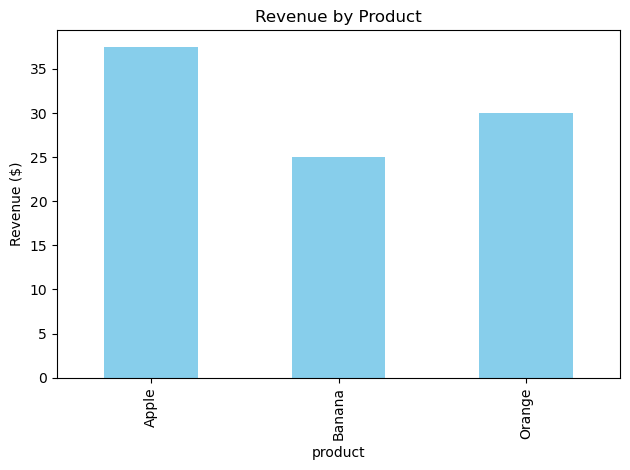

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Connect to SQLite database (creates it if it doesn't exist)
conn = sqlite3.connect("sales_data.db")
cursor = conn.cursor()

# Step 2: Create table and insert sample data
cursor.execute("DROP TABLE IF EXISTS sales")  # reset for re-run
cursor.execute("""
    CREATE TABLE sales (
        id INTEGER PRIMARY KEY,
        product TEXT,
        quantity INTEGER,
        price REAL
    )
""")

# Step 3: Insert sample data
sample_data = [
    ('Apple', 10, 2.5),
    ('Banana', 15, 1.0),
    ('Orange', 8, 1.5),
    ('Apple', 5, 2.5),
    ('Banana', 10, 1.0),
    ('Orange', 12, 1.5),
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()

# Step 4: Run SQL query to get summary
query = """
    SELECT 
        product, 
        SUM(quantity) AS total_qty, 
        SUM(quantity * price) AS revenue 
    FROM sales 
    GROUP BY product
"""
df = pd.read_sql_query(query, conn)

# Step 5: Display the output
print("Sales Summary:\n")
print(df)

# Step 6: Plot revenue bar chart
df.plot(kind='bar', x='product', y='revenue', legend=False, color='skyblue')
plt.title("Revenue by Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

# Step 7: Close the connection
conn.close()
